# API / SDK OpenAI

## SDK OpenAI

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

In [ ]:
client = OpenAI()
client

In [ ]:
messages = [
    {"role": "system", "content": "Opowiedz krótką historię na podany temat"},
    {"role": "user", "content": "Programista"}
]

response = client.responses.create(
    model="gpt-4o-mini",
    input=messages
)
response

In [ ]:
response.output_text

In [ ]:
response.usage

In [ ]:
response.usage.output_tokens, response.usage.input_tokens

## Structured output

*Structured output* to sposób na zmuszenie modelu aby zwrócił odpowiedź zformatowaną jako JSON o zdefinowanym schemacie. Nie wszystkie modele wspierają tę funkcjonalność.

In [ ]:
from pydantic import BaseModel, Field
import json

In [ ]:
class WeatherInfo(BaseModel):
    temperature: float = Field(description="Temperatura wyrażona w kelwinach")
    pressure: float = Field(description="Ciśnienie wyrażone w barach")
    rain: str = Field(description="Informacje na temat deszczu")
    wind: float | None = Field(description="Prędkość wiatru w m/s")

In [ ]:
messages = [
    {"role": "system", "content": "Podsumuj informacje w postaci JSONa"},
    {"role": "user", "content": "W środę było 20 stopni Celsjusza, ciśnienie 1015 hPa i niewielki deszcz"}
]

In [ ]:
response = client.responses.parse(
    model="gpt-4o-mini",
    input=messages,
    temperature=0.7,
    text_format=WeatherInfo
)

In [ ]:
response.output_parsed

In [ ]:
response.output_text

In [ ]:
json.loads(
    response.output_text
)

> **ZADANIA**

## Tiktoken

Tiktoken jest tokenizerem używanym przez modele OpenAI do zamiany tekstu na tokeny. Dzięki niemu możemy m.in. zliczyć tokeny występujące w jakimś tekście na potrzeby oceny czy nie przekraczamy rozmiaru okna kontekstowego.

---

https://platform.openai.com/tokenizer


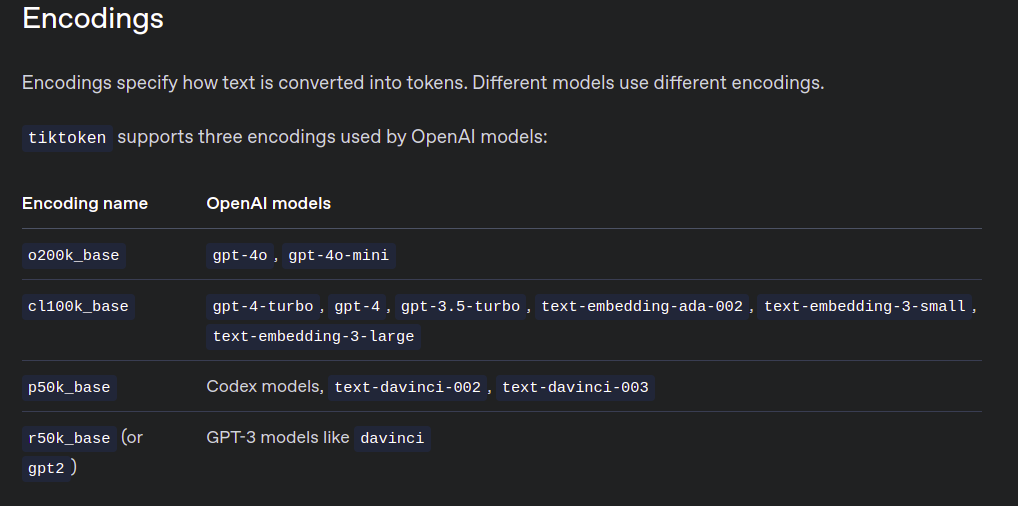

In [ ]:
import tiktoken

In [ ]:
text = response.output_text

In [ ]:
encoding = tiktoken.get_encoding("o200k_base")
tokens = encoding.encode(text)
len(tokens)

In [ ]:
encoding = tiktoken.encoding_for_model("gpt-4o")
tokens = encoding.encode(text)
len(tokens)

> **ZADANIA**